In [18]:
import numpy as np


def clearance_rate_sardine_vdl(prey_length_um, filter_feeding=False):
    """Sardine size-specific clearance rate from Rykaczewski (2019), Eq. 3.

    This is Rykaczewski's modification of van der Lingen (1999), Eq. 5,
    fit to laboratory clearance-rate measurements on adult Sardinops sagax.
    The functional form is a sum of two logistic (sigmoid) terms, one
    centered at 15 µm (fine filter-feeding mechanism) and one centered at
    800 µm (coarser retention mechanism).

    In filter-feeding mode, the clearance rate is clamped flat above
    1230 µm — the value at 1230 µm is used for all larger prey. This
    reflects the biological reality that filter feeding rate is limited
    by water flow through the gill rakers, not by prey size, once prey
    are large enough to be reliably retained.

    Parameters
    ----------
    prey_length_um : array_like
        Prey length in µm. For phytoplankton, this is the longest cell
        dimension; for copepods, this is prosome length (NOT ESD —
        copepod prosome length is typically ~2–3× the ESD of an
        equivalent sphere, so apply a length-conversion factor when
        passing zooplankton ESDs from your size-spectrum grid).
    filter_feeding : bool
        If True (default), apply the >1230 µm clamp for filter feeding.
        If False, return the raw equation value (use with caution
        above ~2.7 mm, where the underlying fit is unreliable).

    Returns
    -------
    F_S : ndarray
        Size-specific clearance rate, same shape as input. Units are
        l fish^-1 min^-1 per prey size class as defined in the source
        paper. For use as a peak-normalized kernel, divide by the
        max value across your grid.

    References
    ----------
    Rykaczewski, R. R. (2019). Changes in mesozooplankton size structure
        along a trophic gradient in the California Current Ecosystem and
        implications for planktivorous fishes. Marine Ecology Progress
        Series, 617–618, 165–182. (Eq. 3)
    van der Lingen, C. D. (1999). The feeding ecology of, and carbon and
        nitrogen budgets for, sardine Sardinops sagax in the southern
        Benguela upwelling system. PhD dissertation, University of Cape
        Town. (Original Eq. 5, which Rykaczewski's Eq. 3 modifies.)
    van der Lingen, C. D. (1994). Effect of particle size and concentration
        on the feeding behaviour of adult pilchard Sardinops sagax.
        Marine Ecology Progress Series, 109, 1–13. (Underlying lab data.)
    """
    x = np.asarray(prey_length_um, dtype=float)

    def _f(xv):
        # First logistic term: fine-filter mechanism, centered at 15 µm
        e1 = np.exp(0.0198 * (xv - 15.0))
        term1 = (9.03 * e1) / (12.03 + 0.75 * e1)

        # Second logistic term: coarser retention, centered at 800 µm
        e2 = np.exp(0.00843 * (xv - 800.0))
        term2 = (9.96 * e2) / (30.8 + 0.323 * e2)

        return term1 + term2

    F_S = _f(x)

    if filter_feeding:
        # Clamp flat above 1230 µm: use the value at 1230 µm everywhere
        # the prey is larger
        F_S_at_1230 = _f(np.array(1230.0))
        F_S = np.where(x > 1230.0, F_S_at_1230, F_S)

    return F_S


def compute_fish_kernel_vdl_joint(phyto_esd, zoo_esd):
    """Sardine feeding kernel on P and Z grids, jointly peak-normalized.

    Evaluates the Rykaczewski (2019) Eq. 3 clearance-rate curve on both
    the phytoplankton and zooplankton ESD grids, then normalizes both
    by the same maximum value so that peak = 1 occurs on whichever grid
    contains the absolute maximum of the curve (typically the zoo grid,
    since the curve peaks near 1230 µm).

    Joint normalization preserves the *relative* weighting between P and
    Z predicted by the clearance-rate curve. Normalizing each grid
    independently would artificially boost the phyto kernel to peak = 1
    even though adult sardines clear large zooplankton much more
    efficiently than small phytoplankton.

    Parameters
    ----------
    phyto_esd : array_like
        Phytoplankton size-class ESDs in µm.
    zoo_esd : array_like
        Zooplankton size-class ESDs in µm. For strict consistency with
        Rykaczewski's equation (which takes copepod prosome length),
        multiply by ~2.5 before passing if you want to correct for
        the length-vs-ESD mismatch.

    Returns
    -------
    kernel_P : ndarray
        Selectivity weights on the phyto grid, same shape as phyto_esd.
    kernel_Z : ndarray
        Selectivity weights on the zoo grid, same shape as zoo_esd.

    Both kernels share a single normalization constant, so the `rate`
    parameter in FishGrazing_Lognormal retains its meaning as the peak
    mass-specific grazing rate per unit fish biomass at the overall
    preferred prey size.

    See Also
    --------
    clearance_rate_sardine_vdl : underlying two-sigmoid curve
    compute_fish_kernel_lognormal : alternative symmetric log-normal kernel
    """
    F_P = clearance_rate_sardine_vdl(phyto_esd)
    F_Z = clearance_rate_sardine_vdl(zoo_esd)
    F_max = max(F_P.max(), F_Z.max())
    return F_P / F_max, F_Z / F_max

In [6]:
import matplotlib.pyplot as plt

In [7]:
from parscan_setup import generate_size_classes

n_classes = 250
phyto_esd = generate_size_classes(n_classes, esd_min=0.5, esd_max=200)
zoo_esd   = generate_size_classes(n_classes, esd_min=5, esd_max=2000)

In [21]:
phyto_grazed, zoo_grazed = compute_fish_kernel_vdl_joint(phyto_esd,zoo_esd)

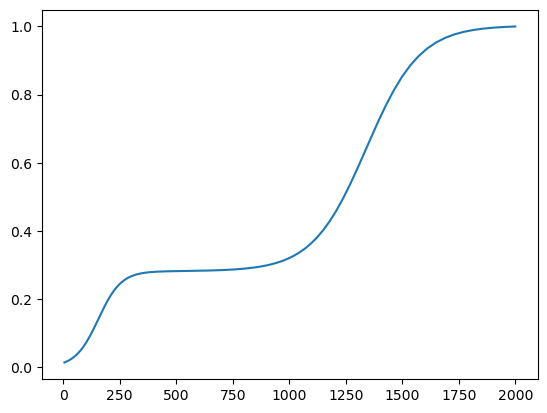

In [22]:
plt.plot(zoo_esd,zoo_grazed)

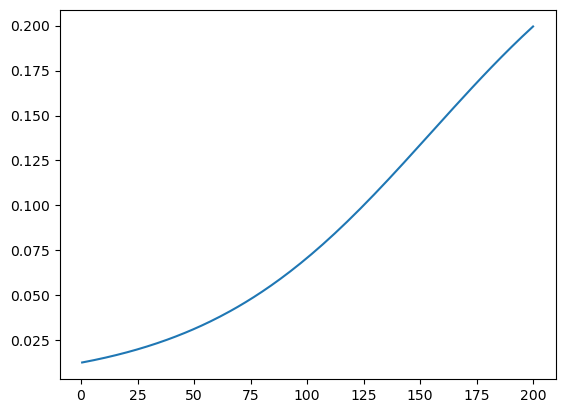

In [23]:
plt.plot(phyto_esd, phyto_grazed)

In [1]:
from cariaco_ssm_parscan import model_setup, model, phyto_esd, zoo_esd

with model:
    model_out = model_setup.xsimlab.run()

model_out['time'] = model_out.time.round(9)

print(model_out)

<xarray.Dataset> Size: 17MB
Dimensions:                                (time: 5000, phyto: 12, zoo: 12,
                                            full: 24, clock: 2)
Coordinates:
  * time                                   (time) float64 40kB 0.0 ... 4.999e+03
  * phyto                                  (phyto) float64 96B 0.5 ... 200.0
  * zoo                                    (zoo) float64 96B 5.0 8.62 ... 2e+03
  * clock                                  (clock) int64 16B 0 1
Dimensions without coordinates: full
Data variables: (12/78)
    Core__solver_type                      <U9 36B 'solve_ivp'
    DetritusRemin__detritus                <U1 4B 'D'
    DetritusRemin__k_remin                 float64 8B 0.1
    DetritusRemin__nutrient                <U1 4B 'N'
    DetritusRemin__remineralization_value  (time) float64 40kB 0.001122 ... 0...
    DetritusSink__detritus                 <U1 4B 'D'
    ...                                     ...
    ZooMortality__population               

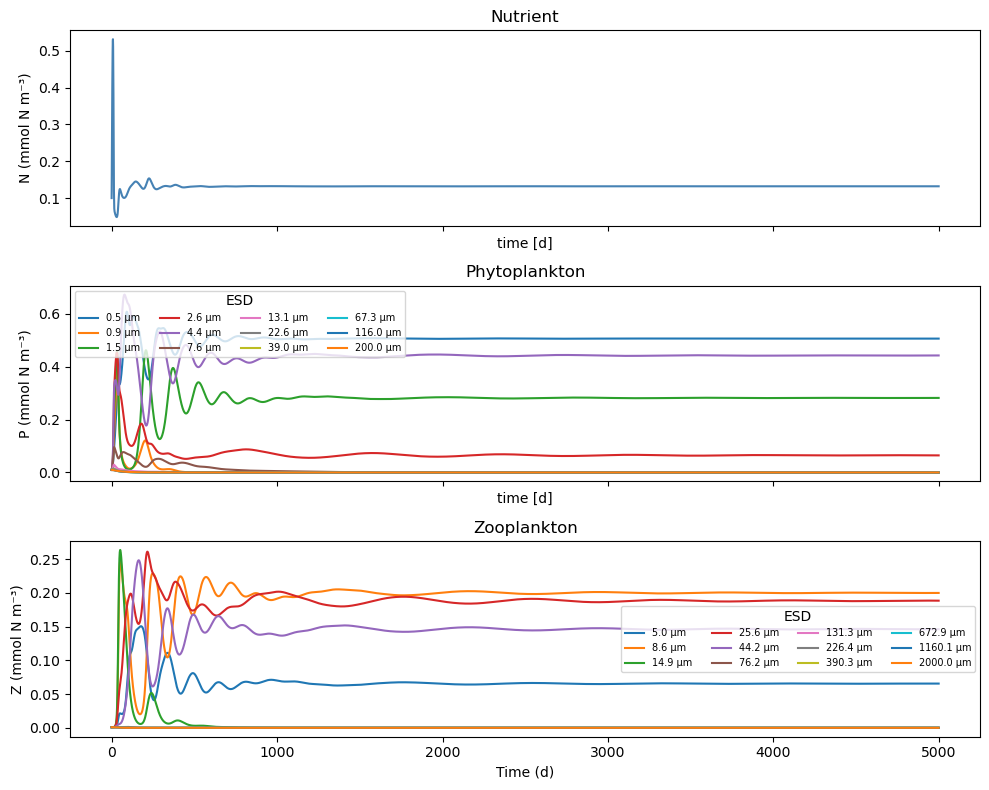

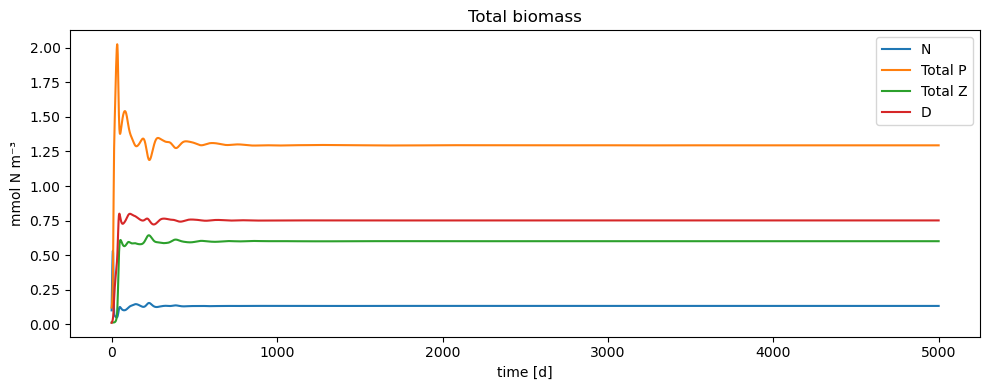


--- Final state (t = 4999 d) ---
  N:       0.1321
  Total P: 1.2945
  Total Z: 0.6005


In [3]:
# %% [markdown]
# ## 11. Quick diagnostic plots

# %%
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- Nutrient ---
ax = axes[0]
model_out['Nutrient__value'].plot(ax=ax, color='steelblue')
ax.set_ylabel('N (mmol N m⁻³)')
ax.set_title('Nutrient')

# --- Phytoplankton ---
ax = axes[1]
P = model_out['Phytoplankton__biomass']
for i, esd in enumerate(phyto_esd):
    P.isel(phyto=i).plot(ax=ax, label=f'{esd:.1f} µm')
ax.set_ylabel('P (mmol N m⁻³)')
ax.set_title('Phytoplankton')
ax.legend(fontsize=7, ncol=4, title='ESD')

# --- Zooplankton ---
ax = axes[2]
Z = model_out['Zooplankton__biomass']
for i, esd in enumerate(zoo_esd):
    Z.isel(zoo=i).plot(ax=ax, label=f'{esd:.1f} µm')
ax.set_ylabel('Z (mmol N m⁻³)')
ax.set_title('Zooplankton')
ax.legend(fontsize=7, ncol=4, title='ESD')

axes[-1].set_xlabel('Time (d)')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 12. Total biomass summary

# %%
total_P = model_out['Phytoplankton__biomass'].sum(dim='phyto')
total_Z = model_out['Zooplankton__biomass'].sum(dim='zoo')
total_N = model_out['Nutrient__value']
total_D = model_out['Detritus__value']

fig, ax = plt.subplots(figsize=(10, 4))
total_N.plot(ax=ax, label='N')
total_P.plot(ax=ax, label='Total P')
total_Z.plot(ax=ax, label='Total Z')
total_D.plot(ax=ax, label='D')
ax.set_ylabel('mmol N m⁻³')
ax.set_title('Total biomass')
ax.legend()
plt.tight_layout()
plt.show()

# Print final-state summary
print(f"\n--- Final state (t = {float(model_out.time[-1]):.0f} d) ---")
print(f"  N:       {float(total_N[-1]):.4f}")
print(f"  Total P: {float(total_P[-1]):.4f}")
print(f"  Total Z: {float(total_Z[-1]):.4f}")

In [9]:
model_out['DetritusSink__sinking_value'] * 50

<xarray.DataArray 'DetritusSink__sinking_value' (time: 5000)> Size: 40kB
array([0.05612371, 0.05612371, 0.06786024, ..., 3.7547425 , 3.75474173,
       3.75474181], shape=(5000,))
Coordinates:
  * time     (time) float64 40kB 0.0 1.0 2.0 ... 4.997e+03 4.998e+03 4.999e+03
Attributes:
    description:    output of flux value / 
    xso_store_out:  True